In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import keras
import tensorflow as tf
import keras.backend as K
from keras.layers import Activation
from keras.layers import Dense , LSTM, Dropout
from keras.models import Sequential, load_model
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import rcParams
import math
import xgboost
import time
from tqdm import tqdm

# Fix the random seed for reproducibility
np.random.seed(1234)
PYTHONHASHSEED = 0

In [ ]:
fd_001_train = pd.read_csv("/content/train_FD001.txt",sep=" ",header=None)

In [ ]:
fd_001_test = pd.read_csv("/content/test_FD001.txt",sep=" ",header=None)

In [ ]:
fd_001_train.describe()

In [ ]:
fd_001_train.drop(columns=[26,27],inplace=True)

In [ ]:
fd_001_test.drop(columns=[26,27],inplace=True)

In [ ]:
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

In [ ]:
fd_001_train.columns = columns

In [ ]:
fd_001_test.columns = columns

In [ ]:
# Initial overview of the training data
fd_001_train.describe()

In [ ]:
# Drop constant columns that do not add state information
fd_001_train.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)

## Mapping Feature Relationships with an RUL Heatmap

To visualise how the variables interact, an additional `RUL` feature is first created for the training set and then used in a correlation heatmap.

In [ ]:
# Build the training frame and add an RUL column
# representing the remaining cycles before failure
def prepare_train_data(data, factor = 0):
    df = data.copy()
    fd_RUL = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    fd_RUL = pd.DataFrame(fd_RUL)
    fd_RUL.columns = ['unit_number','max']
    df = df.merge(fd_RUL, on=['unit_number'], how='left')
    df['RUL'] = df['max'] - df['time_in_cycles']
    df.drop(columns=['max'],inplace = True)

    return df[df['time_in_cycles'] > factor]


In [ ]:
df = prepare_train_data(fd_001_train)

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

## Competition-Style Error Metric

In [ ]:
# Competition-style error function
def score(y_true,y_pred,a1=10,a2=13):
    score = 0
    d = y_pred - y_true
    for i in d:
        if i >= 0 :
            score += math.exp(i/a2) - 1
        else:
            score += math.exp(- i/a1) - 1
    return score

In [ ]:
def score_func(y_true,y_pred):
    lst = [round(score(y_true,y_pred),2),
          round(mean_absolute_error(y_true,y_pred),2),
          round(mean_squared_error(y_true,y_pred),2)**0.5,
          round(r2_score(y_true,y_pred),2)]

    print(f' compatitive score {lst[0]}')
    print(f' mean absolute error {lst[1]}')
    print(f' root mean squared error {lst[2]}')
    print(f' R2 score {lst[3]}')
    return [lst[1], round(lst[2],2), lst[3]*100]


## Feature Reduction Based on Relevance and Redundancy

The following variables are removed because they either show weak association with the RUL target (`setting_1`, `setting_2`, `P15`, `unit_number`) or introduce unnecessary redundancy. In particular, `Nc` and `NRc` are highly correlated, so `NRc` is excluded.

In [ ]:
unit_number = pd.DataFrame(df["unit_number"])
train_df = df.drop(columns = ['unit_number','setting_1','setting_2','P15','NRc'])

In [ ]:
train_df.head()

## LSTM-Based RUL Modelling

### LSTM Data Preparation

In [ ]:
def lstm_data_preprocessing(raw_train_data, raw_test_data, raw_RUL_data):
    train_df = raw_train_data
    truth_df = raw_RUL_data
    truth_df.drop(truth_df.columns[[1]], axis=1, inplace=True)

    #################
    # TRAINING DATA
    #################

    # Create binary warning labels for later classification tasks.
    # `label1` marks whether failure occurs within the chosen horizon `w1`.
    w1 = 30
    w0 = 15
    train_df['label1'] = np.where(train_df['RUL'] <= w1, 1, 0 )
    train_df['label2'] = train_df['label1']
    train_df.loc[train_df['RUL'] <= w0, 'label2'] = 2

    # Apply MinMax scaling to the selected features
    train_df['cycle_norm'] = train_df['time_in_cycles']
    cols_normalize = train_df.columns.difference(['unit_number','time_in_cycles','RUL','label1','label2']) # Scale every feature except identifiers, cycle index, RUL and labels

    min_max_scaler = MinMaxScaler()

    norm_train_df = pd.DataFrame(min_max_scaler.fit_transform(train_df[cols_normalize]),
                                 columns=cols_normalize,
                                 index=train_df.index)

    join_df = train_df[train_df.columns.difference(cols_normalize)].join(norm_train_df)
    train_df = join_df.reindex(columns = train_df.columns)
    print("train_df >> ",train_df.head())
    print("\n")


    #################
    # TEST DATA
    #################

    # Optional alternative preprocessing step kept for reference:
    # raw_test_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)
    test_df = raw_test_data.drop(columns = ['setting_1','setting_2','P15','NRc','max'])

    # Apply MinMax scaling to the selected features
    test_df['cycle_norm'] = test_df['time_in_cycles']
    norm_test_df = pd.DataFrame(min_max_scaler.transform(test_df[cols_normalize]),
                                columns=cols_normalize,
                                index=test_df.index)
    test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
    test_df = test_join_df.reindex(columns = test_df.columns)
    test_df = test_df.reset_index(drop=True)

    # Use the ground-truth file to reconstruct RUL labels for the test set.
    # First compute the last observed cycle for each engine.
    rul = pd.DataFrame(test_df.groupby('unit_number')['time_in_cycles'].max()).reset_index()
    rul.columns = ['unit_number','max']
    truth_df.columns = ['more']
    truth_df['unit_number'] = truth_df.index + 1
    truth_df['max'] = rul['max'] + truth_df['more'] # Add the true extra RUL to the final observed test cycle for each engine
    truth_df.drop('more', axis=1, inplace=True)

    # Rebuild the test-set RUL values
    test_df = test_df.merge(truth_df, on=['unit_number'], how='left')
    test_df['RUL'] = test_df['max'] - test_df['time_in_cycles']
    test_df.drop('max', axis=1, inplace=True)

    # Create the binary warning labels for the test set
    test_df['label1'] = np.where(test_df['RUL'] <= w1, 1, 0 )
    test_df['label2'] = test_df['label1']
    test_df.loc[test_df['RUL'] <= w0, 'label2'] = 2
    print("test_df >> ", test_df.head())


    # Use a sequence window of 50 cycles
    sequence_length = 50

    # Reshape each engine trajectory into rolling sequences
    def gen_sequence(id_df, seq_length, seq_cols):
        """Return only full-length sequences.
        Shorter trajectories are dropped rather than padded.
        """
        # For one engine id, collect all rows into a single matrix
        data_matrix = id_df[seq_cols].values
        num_elements = data_matrix.shape[0]
        # Step through matching start and stop indices in parallel.
        # Example: if one engine has 192 rows and the window length is 50,
        # `zip` pairs the ranges (0, 112) and (50, 192).
        # 0 50  -> rows 0 to 50
        # 1 51  -> rows 1 to 51
        # 2 52  -> rows 2 to 52
        # ...
        # 111 191 -> rows 111 to 191
        for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
            yield data_matrix[start:stop, :]

    # Select the feature columns used in sequence generation
    sequence_cols = list(test_df.columns[:-3])

    print(sequence_cols)

    # Debug check
    # `val` should contain 192 - 50 = 142 arrays of shape (50, 25)
    val=list(gen_sequence(train_df[train_df['unit_number']==1], sequence_length, sequence_cols))
    print(len(val))

    # Build a generator over all engine sequences
    # Convert each engine trajectory into rolling windows
    seq_gen = (list(gen_sequence(train_df[train_df['unit_number']==id], sequence_length, sequence_cols))
               for id in train_df['unit_number'].unique())

    # Materialise the sequence generator as a NumPy array
    seq_array = np.concatenate(list(seq_gen)).astype(np.float32)
    print(seq_array.shape)

    # Create the corresponding target labels
    def gen_labels(id_df, seq_length, label):
        """Return only full-length sequences.
        Shorter trajectories are dropped rather than padded.
        """
        # For one engine id, collect the labels into a single vector.
        # Example label layout:
        # [[1]
        # [4]
        # [1]
        # [5]
        # [9]
        # ...
        # [200]]
        data_matrix = id_df[label].values
        num_elements = data_matrix.shape[0]
        # The first `seq_length` labels are dropped because the first full window
        # uses its last time step as the target. Each later window is aligned in the
        # same rolling manner.
        return data_matrix[seq_length:num_elements, :]

    # Generate the final label array
    label_gen = [gen_labels(train_df[train_df['unit_number']==id], sequence_length, ['RUL'])
                 for id in train_df['unit_number'].unique()]

    label_array = np.concatenate(label_gen).astype(np.float32)
    print(label_array.shape)
    print(label_array)

    return seq_array, label_array, test_df, sequence_length, sequence_cols

### LSTM Regression Model

In [ ]:
def r2_keras(y_true, y_pred):
    """Keras implementation of the coefficient of determination (R²)."""
    SS_res =  tf.reduce_sum(tf.square( y_true - y_pred ))
    SS_tot = tf.reduce_sum(tf.square( y_true - tf.reduce_mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot + K.epsilon()) )

In [ ]:
def lstm_train(seq_array, label_array, sequence_length):
    # Two stacked LSTM layers are used, followed by dropout for regularisation.
    # A single linear output node is kept because the task is regression.
    nb_features = seq_array.shape[2]
    nb_out = label_array.shape[1]

    model = Sequential()
    model.add(LSTM(
             input_shape=(sequence_length, nb_features),
             units=100,
             return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(
              units=50,
              return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=nb_out))
    model.add(Activation("linear"))
    model.compile(loss='mean_squared_error', optimizer='rmsprop',metrics=['mae',r2_keras])

    print(model.summary())

    # Train the network. Many examples use 100 epochs, but 60 is sufficient here.
    history = model.fit(seq_array, label_array, epochs=60, batch_size=200, validation_split=0.05, verbose=2)
    # Optional callbacks such as early stopping or checkpointing can be added here.
    # callbacks = [keras.callbacks.EarlyStoping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
    #              keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]

    # Display the metric keys stored in the training history
    print(history.history.keys())

    return model, history

### Evaluation on the Training/Test Sequence Set

In [ ]:
def lstm_test_evaluation_graphs(model, history, seq_array, label_array):
    # Plot the training history for R²
    fig_acc = plt.figure(figsize=(10, 10))
    plt.plot(history.history['r2_keras'])
    plt.plot(history.history['val_r2_keras'])
    plt.title('LSTM R² over epochs')
    plt.ylabel('R^2')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # fig_acc.savefig("lstm_r2_history.png")

    # Plot the training history for MAE
    fig_acc = plt.figure(figsize=(10, 10))
    plt.plot(history.history['mae'])
    plt.plot(history.history['val_mae'])
    plt.title('LSTM MAE over epochs')
    plt.ylabel('MAE')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # fig_acc.savefig("lstm_mae_history.png")

    # Plot the training history for loss
    fig_acc = plt.figure(figsize=(10, 10))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('LSTM loss over epochs')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # fig_acc.savefig("lstm_loss_history.png")

    # Evaluate the fitted model on the available sequence set
    scores = model.evaluate(seq_array, label_array, verbose=1, batch_size=200)
    print('\nMAE: {}'.format(scores[1]))
    print('\nR^2: {}'.format(scores[2]))

    y_pred = model.predict(seq_array,verbose=1, batch_size=200)
    y_true = label_array

    test_set = pd.DataFrame(y_pred )
    test_set.head()
    # test_set.to_csv('lstm_train_predictions.csv', index=None)

### Evaluation on the Validation Engines

In [ ]:
def lstm_valid_evaluation(lstm_test_df, model, sequence_length, sequence_cols):
    # Keep the final full sequence for each engine in the validation data
    seq_array_test_last = [lstm_test_df[lstm_test_df['unit_number']==id][sequence_cols].values[-sequence_length:]
                           for id in lstm_test_df['unit_number'].unique() if len(lstm_test_df[lstm_test_df['unit_number']==id]) >= sequence_length]

    seq_array_test_last = np.asarray(seq_array_test_last).astype(np.float32)

    # Extract the aligned target labels
    y_mask = [len(lstm_test_df[lstm_test_df['unit_number']==id]) >= sequence_length for id in lstm_test_df['unit_number'].unique()]
    label_array_test_last = lstm_test_df.groupby('unit_number')['RUL'].nth(-1)[y_mask].values
    label_array_test_last = label_array_test_last.reshape(label_array_test_last.shape[0],1).astype(np.float32)

    estimator = model

    # Compute validation metrics
    scores_test = estimator.evaluate(seq_array_test_last, label_array_test_last, verbose=2)
    print('\nMAE: {}'.format(scores_test[1]))
    print('\nR^2: {}'.format(scores_test[2]))

    y_pred_test = estimator.predict(seq_array_test_last)
    y_true_test = label_array_test_last

    test_set = pd.DataFrame(y_pred_test)
    print(test_set.head())

    # Plot predicted and actual RUL values for a quick visual comparison.
    fig_verify = plt.figure(figsize=(10, 5))
    plt.plot(y_pred_test)
    plt.plot(y_true_test, color="orange")
    plt.title('Validation predictions versus actual RUL')
    plt.ylabel('value')
    plt.xlabel('row')
    plt.legend(['predicted', 'actual data'], loc='upper left')
    plt.show()
    # fig_verify.savefig("lstm_validation_predictions.png")
    return scores_test[1], scores_test[2]

### LSTM Reference Sources

- [1] Deep Learning for Predictive Maintenance https://github.com/Azure/lstms_for_predictive_maintenance/blob/master/Deep%20Learning%20Basics%20for%20Predictive%20Maintenance.ipynb
- [2] Predictive Maintenance: Step 2A of 3, train and evaluate regression models https://gallery.cortanaintelligence.com/Experiment/Predictive-Maintenance-Step-2A-of-3-train-and-evaluate-regression-models-2
- [3] A. Saxena and K. Goebel (2008). "Turbofan Engine Degradation Simulation Data Set", NASA Ames Prognostics Data Repository (https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/#turbofan), NASA Ames Research Center, Moffett Field, CA
- [4] Understanding LSTM Networks http://colah.github.io/posts/2015-08-Understanding-LSTMs/
- [5] https://towardsdatascience.com/lstm-for-predictive-maintenance-on-pump-sensor-data-b43486eb3210/#:~:text=Summary%20of%20Steps-,Prerequisite,)%20Matplotlib%20(pip%20install%20matplotlib)

### Helper Function for Training Random Forest and XGBoost Regressors

In [ ]:
# Helper function for fitting the Random Forest and XGBoost models
def train_models(data,model = 'FOREST'):

    if model != 'LSTM':
        X = data.iloc[:,:14].to_numpy()
        Y = data.iloc[:,14:].to_numpy()
        Y = np.ravel(Y)

    if model == 'FOREST':
         # Hyperparameters can be tuned in a simple loop if needed, for example:
         # for i in range(1, 11):
         #     xgb = train_models(train_df, param=i, model="XGB")
         #     y_xgb_i_pred = xgb.predict(X_001_test)
         #     print(f'param = {i}')
         #     score_func(y_true, y_xgb_i_pred)
        model = RandomForestRegressor(n_estimators=70, max_features=7, max_depth=5, n_jobs=-1, random_state=1)
        model.fit(X,Y)
        return model

    elif model == 'XGB':
        model = xgboost.XGBRegressor(n_estimators=110, learning_rate=0.018, gamma=0, subsample=0.8,
                           colsample_bytree=0.5, max_depth=3,silent=True)
        model.fit(X,Y)
        return model

    elif model == 'LSTM':
        seq_array, label_array, lstm_test_df, sequence_length, sequence_cols = lstm_data_preprocessing(data[0], data[1], data[2])
        model_instance, history = lstm_train(seq_array, label_array, sequence_length)
        return model_instance, history, lstm_test_df, seq_array, label_array, sequence_length, sequence_cols

    return

In [ ]:
# Plot actual and predicted RUL values together

def plot_result(y_true,y_pred):
    rcParams['figure.figsize'] = 12,10
    plt.plot(y_pred)
    plt.plot(y_true)
    plt.tick_params(axis='x', which='both', bottom=False, top=False,labelbottom=False)
    plt.ylabel('RUL')
    plt.xlabel('training samples')
    plt.legend(('Predicted', 'True'), loc='upper right')
    plt.title('Actual versus predicted RUL')
    plt.show()
    return

# Preparing Test Inputs for Prediction
Only the features retained during training are used here, together with the final cycle value observed for each engine.

In [ ]:
fd_001_test.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)

In [ ]:
test_max = fd_001_test.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max.columns = ['unit_number','max']

In [ ]:
fd_001_test = fd_001_test.merge(test_max, on=['unit_number'], how='left')

In [ ]:
test = fd_001_test[fd_001_test['time_in_cycles'] == fd_001_test['max']].reset_index()

In [ ]:
test.drop(columns=['index','max','unit_number','setting_1','setting_2','P15','NRc'],inplace = True)

In [ ]:
X_001_test = test.to_numpy()

In [ ]:
X_001_test.shape

In [133]:
fd_001_test.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,max
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,31
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,31
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,31
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,31
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,31


## Generating Final RUL Predictions for All Engines

## Training the Regression Model After Dropping `unit_number`, `setting_1`, `setting_2`, `P15` and `NRc`

In [ ]:
model_1 = train_models(train_df)

In [135]:
y_pred = model_1.predict(X_001_test)

In [136]:
RUL = pd.read_csv("/content/RUL_FD001.txt",sep=" ",header=None)

In [137]:
y_true = RUL[0].to_numpy()

In [138]:
RUL.head()

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN


## Model Performance Summary: Competition Score, MAE, RMSE and R²

In [139]:
RF_individual_scorelst = score_func(y_true, y_pred)

 compatitive score 1057.2
 mean absolute error 19.25
 root mean squared error 24.45219826518671
 R2 score 0.65


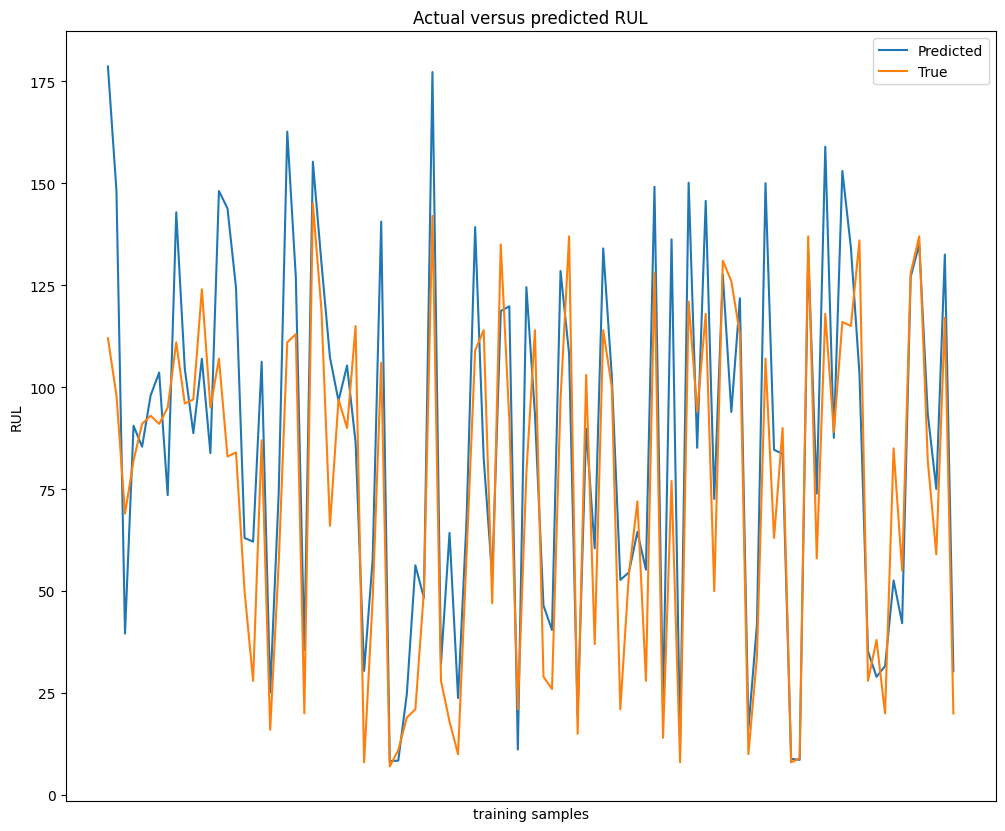

In [140]:
plot_result(y_true,y_pred)

### Running the LSTM Pipeline

In [ ]:
train_df_lstm = pd.concat([unit_number, train_df], axis=1)
model, history, lstm_test_df, seq_array, label_array, sequence_length, sequence_cols = train_models([train_df_lstm, fd_001_test, RUL.copy()], "LSTM")

train_df >>     unit_number  time_in_cycles       T24       T30       T50       P30  \
0            1               1  0.183735  0.406802  0.309757  0.726248   
1            1               2  0.283133  0.453019  0.352633  0.628019   
2            1               3  0.343373  0.369523  0.370527  0.710145   
3            1               4  0.343373  0.256159  0.331195  0.740741   
4            1               5  0.349398  0.257467  0.404625  0.668277   

         Nf        Nc      Ps30       phi       NRf       BPR   htBleed  \
0  0.242424  0.109755  0.369048  0.633262  0.205882  0.363986  0.333333   
1  0.212121  0.100242  0.380952  0.765458  0.279412  0.411312  0.333333   
2  0.272727  0.140043  0.250000  0.795309  0.220588  0.357445  0.166667   
3  0.318182  0.124518  0.166667  0.889126  0.294118  0.166603  0.333333   
4  0.242424  0.149960  0.255952  0.746269  0.235294  0.402078  0.416667   

        W31       W32  RUL  label1  label2  cycle_norm  
0  0.713178  0.724662  191       0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50, 100)        │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,051 (300.98 KB)

 Trainable params: 77,051 (300.98 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
75/75 - 36s - 477ms/step - loss: 8972.5625 - mae: 76.1314 - r2_keras: -1.7740e+00 - val_loss: 8347.8398 - val_mae: 72.9772 - val_r2_keras: -2.5173e+00
Epoch 2/60


In [ ]:
lstm_test_evaluation_graphs(model, history, seq_array, label_array)

In [ ]:
MAE, R2 = lstm_valid_evaluation(lstm_test_df, model, sequence_length, sequence_cols)
# Store MAE and R² for later comparison
LSTM_individual_scorelst = [round(MAE,2), 0, round(R2,2)*100]

### Per-Engine Retraining Strategy

To refine the prediction stage, the model is retrained separately for each engine. Training rows with `time_in_cycles` below the target engine's final observed cycle are excluded so that the model learns from trajectories closer to the relevant degradation stage.

In [ ]:
# The `factor` argument in `prepare_train_data` removes early-cycle rows.
# Each test sample includes the cycle value at which RUL is predicted in its first column.
def single_train(test_data,train_data,algorithm):
    y_single_pred = []
    for sample in tqdm(test_data):
        time.sleep(0.01)
        single_train_df = prepare_train_data(train_data, factor = sample[0])
        single_train_df.drop(columns = ['unit_number','setting_1','setting_2','P15','NRc'],inplace = True)
        model = train_models(single_train_df,algorithm)
        y_p = model.predict(sample.reshape(1,-1))[0]
        y_single_pred.append(y_p)
    y_single_pred = np.array(y_single_pred)
    return y_single_pred

In [ ]:
y_single_pred = single_train(X_001_test,fd_001_train,'FOREST')

### Reviewing the Updated Results

In [ ]:
plot_result(y_true,y_single_pred)

## Performance of the Updated Approach: Competition Score, MAE and R²

In [ ]:
RF_SingleTrain_scorelst = score_func(y_true, y_single_pred)

### The revised per-engine training setup lowers MAE and improves R²

### Averaging Predictions Across Recent Sensor Snapshots

Because the sensor signals are noisy, the estimate is not based on a single final observation. Instead, predictions are generated from several recent time steps and averaged to produce a more stable RUL estimate.

In [ ]:
def prepare_test_data(fd_001_test,n=0):
    test = fd_001_test[fd_001_test['time_in_cycles'] == fd_001_test['max'] - n].reset_index()
    test.drop(columns=['index','max','unit_number','setting_1','setting_2','P15','NRc'],inplace = True)
    X_return = test.to_numpy()
    return X_return

In [ ]:
N=5
y_n_pred = y_single_pred
for i in range(1,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'FOREST')
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred))

### Computing the Mean Prediction for Each Engine

In [ ]:
y_multi_pred = np.mean(y_n_pred,axis = 0)

In [ ]:
RF_5avg_scorelst = score_func(y_true,y_multi_pred)

Results using the average of 5 recent predictions

In [ ]:
plot_result(y_true,y_multi_pred)

In [ ]:
N=10

# Reuse the previously computed 5-step average in `y_multi_pred`.
# Additional predictions are then added for the 6th, 7th, ... recent rows of each engine.
y_n_pred = y_multi_pred
for i in range(5,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'FOREST')
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred))

In [ ]:
y_multi_pred_10 = np.mean(y_n_pred,axis = 0)

In [ ]:
score_func(y_true,y_multi_pred_10)

Results using the average of 10 recent predictions

In [ ]:
plot_result(y_true,y_multi_pred_10)

Using a larger averaging window does not improve performance further, so the 5-prediction average stored in `y_multi_pred` is retained for later analysis.

### Comparing the Approach with XGBoost

In [ ]:
xgb = train_models(train_df,model="XGB")

In [ ]:
y_xgb_pred = xgb.predict(X_001_test)

In [ ]:
XGB_individual_scorelst = score_func(y_true,y_xgb_pred)

Under the regression metrics used here, XGBoost performs worse than the random forest benchmark.

Reference RandomForestRegressor results:

Competition Score 1057.2

Mean absolute error 19.25

Root mean squared error 24.45219826518671

R² score 0.65

In [ ]:
plot_result(y_true,y_xgb_pred)

Per-engine XGBoost predictions:

In [ ]:
y_single_xgb_pred = single_train(X_001_test,fd_001_train,'XGB')

In [ ]:
XGB_SingleTrain_scorelst = score_func(y_true,y_single_xgb_pred)

In [ ]:
plot_result(y_true,y_single_xgb_pred)

In [ ]:
N=5
y_n_pred = y_single_xgb_pred
for i in range(1,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'XGB')
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred))

In [ ]:
y_5_pred_xgb = np.mean(y_n_pred,axis = 0)

In [ ]:
XGB_5avg_scorelst = score_func(y_true,y_5_pred_xgb)

Compared with the joint-prediction setup, most metrics improve here, although the competition score does not.

In [ ]:
plot_result(y_true,y_5_pred_xgb)

In [ ]:
# Bar plots for model comparison
def Bar_Plots(RF_score_lst, XGB_score_lst, LSTM_score_lst=0):
    hue = ["mae","rmse", "r2"]

    if LSTM_score_lst != 0:
        df = pd.DataFrame(zip(hue*3, ["RFRegrssor"]*3+["LSTM"]*3+["XGBRegressor"]*3, RF_score_lst+LSTM_score_lst+XGB_score_lst), columns=["Parameters", "Models", "Scores"])
    else:
        df = pd.DataFrame(zip(hue*3, ["RFRegrssor"]*3+["XGBRegressor"]*3, RF_score_lst+XGB_score_lst), columns=["Parameters", "Models", "Scores"])

    print(df.head(10))
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Models", y="Scores", hue="Parameters", data=df)
    plt.show()

In [ ]:
# Comparison of individual-prediction metrics
# LSTM_individual_scorelst = [17.36, 0, 75]  # Use this placeholder only if the full LSTM run is skipped
Bar_Plots(RF_individual_scorelst, XGB_individual_scorelst, LSTM_individual_scorelst)

In [ ]:
# Comparison for the single-train setup
Bar_Plots(RF_SingleTrain_scorelst, XGB_SingleTrain_scorelst)

In [ ]:
# Comparison for the 5-prediction average
Bar_Plots(RF_5avg_scorelst, XGB_5avg_scorelst)

In [ ]:
compare = pd.DataFrame(list(zip(y_true, y_pred, y_single_pred,y_multi_pred,y_multi_pred_10,y_xgb_pred,y_single_xgb_pred)),
               columns =['True','Forest_Predicted','Forest_Single_predicted','multi_5','multi_10'
                         ,'XGBoost','XGBoost_single'])
compare['unit_number'] = compare.index + 1

In [ ]:
compare['Predicted_error'] = compare['True'] - compare['Forest_Predicted']
compare['Single_pred_error'] = compare['True'] - compare['Forest_Single_predicted']
compare['multi_5_error'] = compare['True'] - compare['multi_5']
compare['multi_10_error'] = compare['True'] - compare['multi_10']
compare['xgb_error'] = compare['True'] - compare['XGBoost']
compare['xgb_single_error'] = compare['True'] - compare['XGBoost_single']
ax1 = compare.plot(subplots=True, sharex=True, figsize=(20,20))

Prediction errors remain strongly correlated across the models, suggesting that further improvement may depend on stronger preprocessing and explicit outlier handling.

## Binary Classification for Maintenance Decisions

To give the analysis more practical value, the problem is also framed as a binary maintenance decision task. This makes it possible to estimate the potential financial impact of acting on the model outputs for a hypothetical airline.

Reference implementation inspiration:
https://github.com/Samimust/predictive-maintenance/blob/master/Model%20Selection%20-%20Binary%20Classifiaction.ipynb

The classifier below answers a simple operational question: does the engine have more than 10 cycles remaining, or not? A 10-cycle threshold is treated as enough time to prepare and begin maintenance.

## Expected Value Calculation

Following the decision-analysis idea presented in the book:*Business Data Science: Combining Machine Learning and Economics to Optimize, Automate, and Accelerate Business Decisions by Matt Taddy*, expected value can be used to compare classification models through a cost-benefit matrix aligned with the confusion matrix. Multiplying the confusion matrix by this cost-benefit matrix converts predictive performance into a single monetary estimate.

The exact values should ideally be defined by a domain expert. For this notebook, the following illustrative assumptions are used:

True Positive (TP): benefit of USD 300K — an engine genuinely needs maintenance and is correctly flagged by the model.

True Negative (TN): benefit of USD 0K — an engine does not need maintenance and is correctly left unflagged.

False Positive (FP): cost of USD -100K — an engine is healthy but is unnecessarily selected for maintenance.

False Negative (FN): cost of USD -200K — an engine needs maintenance but is missed by the model.

In [ ]:
# Create the binary target label using TTF (time to failure)
TTF = 10
train_df['label'] = np.where(train_df['RUL'] <= TTF, 1, 0 )

### Creating the TTF-Based Target Label

In [ ]:
train_df.head()

A scatter plot is used below to see how two selected variables separate under the binary target label.

In [ ]:
sns.scatterplot(x="Nc", y="T50", hue="label", data=train_df)
plt.title('Scatter plot of Nc versus T50 by class label')

## Building the Classification Dataset

In [ ]:
# Remove the RUL column and split features from the target label
X_class = train_df.iloc[:,:14].to_numpy()
Y_class = train_df.iloc[:,15:].to_numpy()
Y_class = np.ravel(Y_class)

In [ ]:
# Balance the classes to improve classifier learning
from imblearn.over_sampling import RandomOverSampler
# from imblearn.under_sampling import RandomUnderSampler
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X_class, Y_class)
print('The number of elements before the operation:', len(X_class))
print('The number of elements after the operation:', len(X_resampled))

In [ ]:
# Split the balanced dataset into training and test partitions.
# `test_size=0.2` keeps 20% of the data for evaluation.
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size = 0.2,random_state = 3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
forest = RandomForestClassifier(n_estimators=70 ,max_depth = 8, random_state=193)
forest.fit(X_train,y_train)

In [ ]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
def classificator_score(y_,y_p):
    print(f' accuracy score {round(accuracy_score(y_, y_p),2)}')
    print(f' precision score {round(precision_score(y_, y_p),2)}')
    print(f' recall score {round(recall_score(y_, y_p),2)}')
    print(f' F1 score {round(f1_score(y_, y_p),2)}')
    return

RandomForestClassifier performance

In [ ]:
classificator_score(y_test,forest.predict(X_test))

In [ ]:
y_xgb_pred = model_xgb.predict(X_001_test)
classificator_score(y_test,model_xgb.predict(X_test))

In [ ]:
test.head()

In [ ]:
X_001_test = test.to_numpy()

### Combined Table of Predicted and True Labels

In [ ]:
# Generate predictions for `X_001_test` using the TTF = 10 threshold
predicted = pd.DataFrame()
predicted ['forest'] =  forest.predict(X_001_test)
predicted['XGB'] = y_xgb_pred
predicted['RUL']=RUL[0]
predicted['true_label'] = np.where(y_true <= TTF, 1, 0 )
predicted['unit_number'] = predicted.index + 1

In [ ]:
predicted.head()

In [ ]:
# Engines whose true TTF is 10 cycles or less
predicted[predicted['true_label'] == 1]

In [ ]:
# Engines misclassified by the RandomForest model
predicted[predicted['true_label'] != predicted['forest']]

In [ ]:
# Engines misclassified by the XGBoost model
predicted[predicted['true_label'] != predicted['XGB']]

In [ ]:
y_true_class = np.where(y_true <= TTF, 1, 0 )
y_pred_class = predicted['forest'].tolist()

### Function for Estimating Expected Profit

In [ ]:
def expected_profit(y_true,y_pred):
    TP=0
    FP=0
    TN=0
    FN=0
    for i in range(len(y_true)):
        if (y_true[i] != y_pred[i]) & (y_pred[i] == 1):
            FP += 1
        elif (y_true[i] != y_pred[i]) & (y_pred[i] == 0):
            FN += 1
        elif (y_true[i] == y_pred[i]) & (y_pred[i] == 0):
            TN += 1
        else:
            TP += 1
    print(f'TP ={TP}, TN = {TN}, FP = {FP}, FN = {FN}')
    print (f'expected profit {(300 * TP - 200 * FN - 100 * FP) * 1000}')
    return


In [ ]:
def confusion_matrix(actual, predicted):
    plt.figure(figsize=(5,5))
    sns.heatmap(sklearn.metrics.confusion_matrix(actual,predicted),annot=True,fmt='.5g')
    plt.ylabel('actual class')
    plt.xlabel('predicted class')
    plt.show()

In [ ]:
# Random forest expected profit and confusion matrix
expected_profit(y_true_class,y_pred_class)
confusion_matrix(y_true_class, y_pred_class)

In [ ]:
def expected_profit(y_true,y_pred):
    TP=0
    FP=0
    TN=0
    FN=0
    for i in range(len(y_true)):
        if (y_true[i] != y_pred[i]) & (y_pred[i] == 1):
            FP += 1
        elif (y_true[i] != y_pred[i]) & (y_pred[i] == 0):
            FN += 1
        elif (y_true[i] == y_pred[i]) & (y_pred[i] == 0):
            TN += 1
        else:
            TP += 1
    print(f'TP ={TP}, TN = {TN}, FP = {FP}, FN = {FN}')
    print (f'expected profit {(300 * TP - 200 * FN - 100 * FP) * 1000}')
    return

def confusion_matrix(actual, predicted):
    plt.figure(figsize=(5,5))
    sns.heatmap(sklearn.metrics.confusion_matrix(actual,predicted),annot=True,fmt='.5g')
    plt.ylabel('actual class')
    plt.xlabel('predicted class')
    plt.show()

# XGBoost expected profit and confusion matrix
expected_profit(y_true_class,y_xgb_pred)
confusion_matrix(y_true_class, y_xgb_pred)

# --- User-provided hypothetical scenario calculation ---
print('\n--- Calculation for User-provided values ---')
TP_user = 5
TN_user = 90
FP_user = 3
FN_user = 2
expected_profit_user = (300 * TP_user - 200 * FN_user - 100 * FP_user) * 1000
print(f'TP ={TP_user}, TN = {TN_user}, FP = {FP_user}, FN = {FN_user}')
print(f'Expected profit for user-provided values: {expected_profit_user}')

### ROC Curve

In [ ]:
fpr_xgb, tpr_xgb, _ = metrics.roc_curve(y_true_class,  y_xgb_pred)
fpr_RF, tpr_RF, _ = metrics.roc_curve(y_true_class,  y_pred_class)
auc_xgb = metrics.auc(fpr_xgb,  tpr_xgb)
auc_RF = metrics.auc(fpr_RF,  tpr_RF)

plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb,tpr_xgb, label='XGBoost ROC (area = %0.2f)' % auc_xgb)
plt.plot(fpr_RF,tpr_RF, label='Random Forest ROC (area = %0.2f)' % auc_RF)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.show()

## Conclusion

The classification models produce practically useful test-set results and could support cost-aware preventive maintenance decisions. Where an approximate RUL estimate is also needed, this classification layer can be used alongside the regression models developed earlier in the notebook.